# Credit Risk Analysis & Loan Default Prediction

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

###1. Data Loading

In [ ]:
df = pd.read_csv("/content/Loan_default.csv")

### 2. Data Understanding

In [ ]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [ ]:
df.shape

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
df.dtypes

## 3. Data Quality Check

In [ ]:
df.isnull().sum()

In [ ]:
df.duplicated().sum()

## 4. Exploratory Data Analysis

### 4.1 Default Distribution


In [ ]:
df["Default"].value_counts()

In [ ]:
import matplotlib.pyplot as plt

df["Default"].value_counts().plot(kind="bar")

plt.title("Loan Default Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Loans")
plt.xticks([0, 1], ["No Default", "Default"], rotation=0)

plt.show()

### 4.2 Credit Score Analysis


In [ ]:
df.groupby("Default")["CreditScore"].mean()

In [ ]:
df["CreditScoreGroup"] = pd.cut(
    df["CreditScore"],
    bins=[299, 499, 599, 699, 849],
    labels=["Low", "Fair", "Good", "High"]
)


In [ ]:
df.groupby(
    "CreditScoreGroup",
    observed=True
)["Default"].mean() * 100

### 4.3 Income Analysis


In [ ]:
df["IncomeGroup"] = pd.qcut(
    df["Income"],
    q=4,
    labels=["Low", "Lower-Middle", "Upper-Middle", "High"]
)

df.groupby(
    "IncomeGroup",
    observed=True
)["Default"].mean() * 100

### 4.4 Loan Amount Analysis


In [ ]:
df["LoanAmountGroup"] = pd.qcut(
    df["LoanAmount"],
    q=4,
    labels=["Low", "Lower-Middle", "Upper-Middle", "High"]
)

loan_default_rate = (
    df.groupby("LoanAmountGroup", observed=True)["Default"]
      .mean()
      .mul(100)
      .reset_index()
)

loan_default_rate

### 4.5 DTI Ratio Analysis


In [ ]:
df["DTIGroup"] = pd.qcut(
    df["DTIRatio"],
    q=4,
    labels=["Low", "Lower-Middle", "Upper-Middle", "High"]
)

dti_default_rate = (
    df.groupby("DTIGroup", observed=True)["Default"]
      .mean()
      .mul(100)
      .reset_index()
)

dti_default_rate

### 4.6 Interest Rate Analysis


In [ ]:
df["InterestRateGroup"] = pd.qcut(
    df["InterestRate"],
    q=4,
    labels=["Low", "Lower-Middle", "Upper-Middle", "High"]
)

interest_default_rate = (
    df.groupby("InterestRateGroup", observed=True)["Default"]
      .mean()
      .mul(100)
      .reset_index()
)

interest_default_rate

### 4.7 Categorical Analysis


In [ ]:
employment_default_rate = (
    df.groupby("EmploymentType")["Default"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .reset_index()
)

employment_default_rate

In [ ]:
education_default_rate = (
    df.groupby("Education")["Default"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .reset_index()
)

education_default_rate

In [ ]:
loan_purpose_default_rate = (
    df.groupby("LoanPurpose")["Default"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .reset_index()
)

loan_purpose_default_rate

In [ ]:
for col in ["HasMortgage", "HasDependents", "HasCoSigner"]:
    print(f"\n{col}")
    print(
        df.groupby(col)["Default"]
          .mean()
          .mul(100)
          .sort_values(ascending=False)
    )

##5. Data Visualization


### 5.1 Default Distribution

In [ ]:
import matplotlib.pyplot as plt

default_counts = df["Default"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(
    ["No Default", "Default"],
    [default_counts[0], default_counts[1]]
)

plt.title("Loan Default Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Loans")
plt.show()

### 5.2 Credit Score vs Default

In [ ]:
import matplotlib.pyplot as plt

credit_default = (
    df.groupby("CreditScoreGroup", observed=True)["Default"]
      .mean()
      .mul(100)
)

plt.figure(figsize=(7, 4))
plt.bar(credit_default.index.astype(str), credit_default.values)

plt.title("Default Rate by Credit Score Group")
plt.xlabel("Credit Score Group")
plt.ylabel("Default Rate (%)")

plt.show()

### 5.3 Income vs Default

In [ ]:
income_default = (
    df.groupby("IncomeGroup", observed=True)["Default"]
      .mean()
      .mul(100)
)

plt.figure(figsize=(7, 4))
plt.bar(income_default.index.astype(str), income_default.values)

plt.title("Default Rate by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Default Rate (%)")

plt.show()

### 5.4 Loan Amount vs Default

In [ ]:
loan_default = (
    df.groupby("LoanAmountGroup", observed=True)["Default"]
      .mean()
      .mul(100)
)

plt.figure(figsize=(7, 4))
plt.bar(loan_default.index.astype(str), loan_default.values)

plt.title("Default Rate by Loan Amount Group")
plt.xlabel("Loan Amount Group")
plt.ylabel("Default Rate (%)")

plt.show()

### 5.5 DTI Ratio vs Default

In [ ]:
dti_default = (
    df.groupby("DTIGroup", observed=True)["Default"]
      .mean()
      .mul(100)
)

plt.figure(figsize=(7, 4))
plt.bar(dti_default.index.astype(str), dti_default.values)

plt.title("Default Rate by DTI Ratio Group")
plt.xlabel("DTI Ratio Group")
plt.ylabel("Default Rate (%)")

plt.show()

### 5.6 Interest Rate vs Default

In [ ]:
interest_default = (
    df.groupby("InterestRateGroup", observed=True)["Default"]
      .mean()
      .mul(100)
)

plt.figure(figsize=(7, 4))
plt.bar(interest_default.index.astype(str), interest_default.values)

plt.title("Default Rate by Interest Rate Group")
plt.xlabel("Interest Rate Group")
plt.ylabel("Default Rate (%)")

plt.show()

### 5.6 Interest Rate vs Default

In [ ]:
plt.figure(figsize=(7, 4))

employment_default = (
    df.groupby("EmploymentType")["Default"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

plt.bar(
    employment_default.index,
    employment_default.values
)

plt.title("Default Rate by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=30)

plt.show()

### 5.7 Employment Type vs Default

In [ ]:
plt.figure(figsize=(7, 4))

loan_purpose_default = (
    df.groupby("LoanPurpose")["Default"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

plt.bar(
    loan_purpose_default.index,
    loan_purpose_default.values
)

plt.title("Default Rate by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=30)

plt.show()

## 6. Key Business Insights

- Overall loan default rate was approximately 11.61%.
- Higher interest-rate groups showed higher default rates.
- Higher loan amounts were associated with higher default rates.
- Lower-income groups showed higher observed default rates.
- Higher DTI groups showed a gradual increase in default rates.
- Higher credit-score groups showed lower observed default rates.

## 7. SQL Analysis

In [ ]:
import sqlite3

conn = sqlite3.connect("credit_risk.db")

df.to_sql(
    "loan_data",
    conn,
    if_exists="replace",
    index=False
)

In [ ]:
query = """
SELECT *
FROM loan_data
LIMIT 10;
"""

pd.read_sql_query(query, conn)

In [ ]:
query = """
SELECT
    COUNT(*) AS total_loans,
    SUM("Default") AS total_defaults,
    ROUND(AVG("Default") * 100, 2) AS default_rate
FROM loan_data;
"""

pd.read_sql_query(query, conn)

### 7.1 Default Rate by Employment Type

In [ ]:
query = """
SELECT
    EmploymentType,
    COUNT(*) AS total_loans,
    SUM("Default") AS total_defaults,
    ROUND(AVG("Default") * 100, 2) AS default_rate
FROM loan_data
GROUP BY EmploymentType
ORDER BY default_rate DESC;
"""

pd.read_sql_query(query, conn)

In [ ]:
query = """
SELECT
    LoanPurpose,
    COUNT(*) AS total_loans,
    SUM("Default") AS total_defaults,
    ROUND(AVG("Default") * 100, 2) AS default_rate
FROM loan_data
GROUP BY LoanPurpose
ORDER BY default_rate DESC;
"""

pd.read_sql_query(query, conn)

In [ ]:
query = """
SELECT
    "Default" AS default_status,
    COUNT(*) AS total_loans,
    ROUND(AVG(LoanAmount), 2) AS avg_loan_amount
FROM loan_data
GROUP BY "Default"
ORDER BY "Default";
"""

pd.read_sql_query(query, conn)

### 7.3 Default Rate by Income Group

In [ ]:
query = """
SELECT
    Income,
    COUNT(*) AS total_loans,
    SUM("Default") AS total_defaults,
    ROUND(AVG("Default") * 100, 2) AS default_rate
FROM loan_data
GROUP BY Income
ORDER BY default_rate DESC;
"""

pd.read_sql_query(query, conn)

In [ ]:
query = """
SELECT
    CreditScoregroup,
    COUNT(*) AS total_loans,
    SUM("Default") AS total_defaults,
    ROUND(AVG("Default") * 100, 2) AS default_rate
FROM loan_data
GROUP BY CreditScoregroup
ORDER BY default_rate DESC;
"""

pd.read_sql_query(query, conn)

In [ ]:
"LoanAmountGroup" in df.columns
query = """
SELECT
    LoanAmountGroup,
    COUNT(*) AS total_loans,
    SUM("Default") AS total_defaults,
    ROUND(AVG("Default") * 100, 2) AS default_rate
FROM loan_data
GROUP BY LoanAmountGroup
ORDER BY default_rate DESC;
"""

pd.read_sql_query(query, conn)

In [ ]:
query = """
SELECT
    DTIGroup,
    COUNT(*) AS total_loans,
    SUM("Default") AS total_defaults,
    ROUND(AVG("Default") * 100, 2) AS default_rate
FROM loan_data
GROUP BY DTIGroup
ORDER BY default_rate DESC;
"""

pd.read_sql_query(query, conn)

In [ ]:
query = """
SELECT
    InterestRateGroup,
    COUNT(*) AS total_loans,
    SUM("Default") AS total_defaults,
    ROUND(AVG("Default") * 100, 2) AS default_rate
FROM loan_data
GROUP BY InterestRateGroup
ORDER BY default_rate DESC;
"""

pd.read_sql_query(query, conn)

In [ ]:
query = """
SELECT
    InterestRateGroup,
    DTIGroup,
    COUNT(*) AS total_loans,
    SUM("Default") AS total_defaults,
    ROUND(AVG("Default") * 100, 2) AS default_rate
FROM loan_data
GROUP BY InterestRateGroup, DTIGroup
HAVING COUNT(*) >= 100
ORDER BY default_rate DESC;
"""

pd.read_sql_query(query, conn)

## 8. Machine Learning – Loan Default Prediction

In [ ]:
X = df.drop(columns=["Default", "LoanID"])
y = df["Default"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (255347, 16)
Target: (255347,)


In [ ]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']

Categorical Features:
['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (204277, 16)
Testing data: (51070, 16)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training data after preprocessing:", X_train_processed.shape)
print("Testing data after preprocessing:", X_test_processed.shape)

Training data after preprocessing: (204277, 31)
Testing data after preprocessing: (51070, 31)


In [ ]:
from sklearn.linear_model import SGDClassifier

baseline_model = SGDClassifier(
    loss="log_loss",
    class_weight="balanced",
    random_state=42,
    max_iter=1000,
    n_jobs=-1
)

baseline_model.fit(X_train_processed, y_train)

SGDClassifier(class_weight='balanced', loss='log_loss', n_jobs=-1,
              random_state=42)

In [ ]:
y_pred = baseline_model.predict(X_test_processed)
y_prob = baseline_model.predict_proba(X_test_processed)[:, 1]

print("Predictions created successfully.")

Predictions created successfully.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1-Score:", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))

Accuracy: 0.8839
Precision: 0.5
Recall: 0.0427
F1-Score: 0.0786
ROC-AUC: 0.5186


[[44886   253]
 [ 5678   253]]


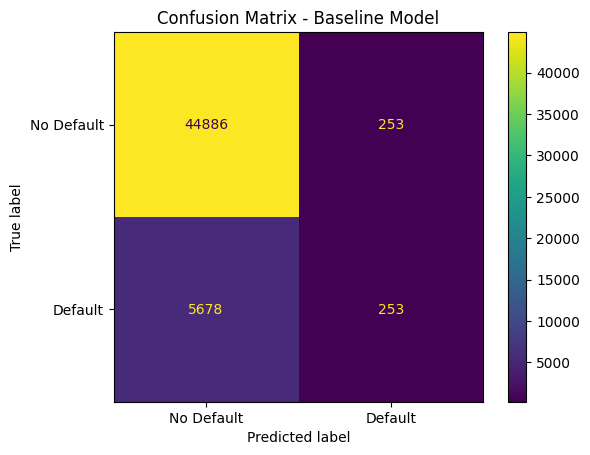

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Default", "Default"]
).plot()

plt.title("Confusion Matrix - Baseline Model")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=12, n_jobs=-1,
                       random_state=42)

In [ ]:
rf_pred = rf_model.predict(X_test_processed)
rf_prob = rf_model.predict_proba(X_test_processed)[:, 1]

print("Predictions created successfully.")

Predictions created successfully.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy:", round(accuracy_score(y_test, rf_pred), 4))
print("Precision:", round(precision_score(y_test, rf_pred), 4))
print("Recall:", round(recall_score(y_test, rf_pred), 4))
print("F1-Score:", round(f1_score(y_test, rf_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, rf_prob), 4))

Accuracy: 0.7779
Precision: 0.2712
Recall: 0.5405
F1-Score: 0.3612
ROC-AUC: 0.7527


In [ ]:
model_comparison = pd.DataFrame({
    "Model": ["SGD Classifier", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,SGD Classifier,0.8839,0.5000,0.0427,0.0786,0.5186
1,Random Forest,0.7779,0.2712,0.5405,0.3612,0.7527


[[36523  8616]
 [ 2725  3206]]


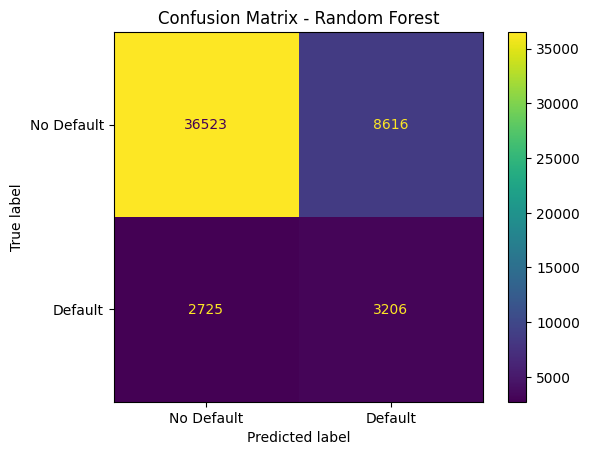

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Default", "Default"]
).plot()

plt.title("Confusion Matrix - Random Forest")
plt.show()

In [ ]:
feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

importance.head(15)

,Feature,Importance
0,num__Age,0.214812
6,num__InterestRate,0.160515
1,num__Income,0.138049
4,num__MonthsEmployed,0.102144
2,num__LoanAmount,0.101520
3,num__CreditScore,0.059335
8,num__DTIRatio,0.048178
7,num__LoanTerm,0.017965
5,num__NumCreditLines,0.017941
13,cat__EmploymentType_Full-time,0.010109


## 9. Final Business Insights

- Overall loan default rate was approximately 11.61%.
- Unemployed borrowers showed the highest default rate among employment categories, while full-time borrowers showed the lowest.
- Higher loan amount groups showed progressively higher default rates, with the High loan amount group having the highest observed default rate.
- Higher DTI groups showed a gradual increase in default rates.
- Higher interest-rate groups showed substantially higher default rates.
- Lower credit-score groups showed higher observed default rates than higher credit-score groups.
- Business-purpose loans showed the highest default rate among the analyzed loan purposes.
- The Random Forest model was evaluated using Precision, Recall, F1-Score and ROC-AUC rather than relying only on accuracy because the target classes were imbalanced.
- The confusion matrix showed that some actual defaulters were still missed, highlighting the importance of improving recall in credit-risk applications.